# Trabajo Práctico Final - Aprendizaje de Máquina I (CEIA - FIUBA)

## Detección de fugas internas en la bomba de un sistema hidráulico

**Integrantes:** Nelson Martín Villagra y Víctor Hugo Astorga

**Fecha:** octubre de 2026

## 1. Introducción

### El problema

Trabajamos con datos de un banco de pruebas hidráulico armado por ZeMA, un centro de investigación alemán. El banco repite siempre el mismo ciclo de trabajo de 60 segundos y en cada ciclo registra 17 sensores: presiones, caudales, temperaturas, potencia del motor, vibración y algunos valores calculados de eficiencia. Mientras el banco funcionaba, los investigadores fueron provocando a propósito fallas de distinta gravedad en cuatro componentes: el enfriador, una válvula, la bomba y un acumulador.

De todo eso elegimos estudiar **una sola variable de salida: el estado de la bomba principal**, que tiene tres valores posibles:

| Valor | Significado | Ciclos |
|---|---|---|
| 0 | sin fuga | 1221 |
| 1 | fuga leve | 492 |
| 2 | fuga severa | 492 |

Una fuga interna en la bomba quiere decir que parte del aceite que la bomba empuja se vuelve para atrás en lugar de ir al circuito. En el banco la simularon abriendo pequeños orificios de desvío. La bomba sigue andando, pero rinde menos, y si nadie se da cuenta la falla puede empeorar.

### La pregunta que queremos responder

> ¿Podemos saber si la bomba tiene una fuga, y qué tan grave es, mirando solamente lo que miden los sensores durante un ciclo de 60 segundos?

En el lenguaje de la materia es un problema de **aprendizaje supervisado** (tenemos ejemplos con la respuesta correcta, la *etiqueta*) de **clasificación multiclase** (la respuesta es una de tres categorías).

### ¿Por qué la bomba y no los otros componentes?

Antes de decidir miramos los cuatro:

- **Enfriador:** se adivina casi perfecto con un solo sensor (CE, eficiencia de enfriamiento). Además, cada uno de sus tres estados ocupa un solo bloque de tiempo (ciclos 1 a 732, 733 a 1464 y 1465 a 2205), así que no hay forma de separar un conjunto de test que tenga las tres clases sin mezclar ciclos casi idénticos.
- **Válvula:** mirando las señales vimos que alcanza con medir cuánto tarda en caer la presión PS1 cerca del segundo 9,5 del ciclo. Una válvula deteriorada tarda más en cambiar de posición y con un umbral sobre ese tiempo se clasifica casi sin error. No le deja mucho trabajo a un modelo.
- **Acumulador:** sus estados cambian muy lento, y en la parte del experimento que podíamos usar como test sólo aparecen dos de sus cuatro estados.
- **Bomba:** las tres clases aparecen repartidas a lo largo de todo el experimento, y como vamos a ver, una regla simple sirve pero no alcanza. Es el caso en el que tiene sentido probar modelos.

### Fuente de los datos

- Dataset (lo descargamos de Kaggle): https://www.kaggle.com/datasets/jjacostupa/condition-monitoring-of-hydraulic-systems
- Es una copia del original publicado en el UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/447/condition+monitoring+of+hydraulic+systems
- Paper de los autores del dataset: N. Helwig, E. Pignanelli y A. Schütze, *Condition Monitoring of a Complex Hydraulic System Using Multivariate Statistics*, IEEE I2MTC 2015. doi: 10.1109/I2MTC.2015.7151267

### Cómo correr este notebook

1. Descargar el dataset desde el link de Kaggle (botón *Download*) y descomprimirlo en una carpeta `data/` al lado de este notebook. Tienen que quedar los archivos `data/PS1.txt`, `data/FS1.txt`, ..., `data/profile.txt`. El zip pesa unos 90 MB y descomprimido unos 550 MB.
2. Instalar las dependencias con `uv sync` (están en `pyproject.toml`).
3. Ejecutar todas las celdas en orden. Tarda unos 3 minutos; la mayor parte es la búsqueda de hiperparámetros.

## 2. Carga de los datos

Cada sensor viene en un archivo de texto separado por tabulaciones: **una fila por ciclo** (2205 ciclos) y **una columna por cada medición dentro del ciclo**. Como no todos los sensores miden igual de rápido, la cantidad de columnas cambia:

| Sensores | Qué miden | Mediciones por segundo | Columnas por ciclo |
|---|---|---|---|
| PS1 a PS6 | presión (bar) | 100 | 6000 |
| EPS1 | potencia del motor (W) | 100 | 6000 |
| FS1, FS2 | caudal (l/min) | 10 | 600 |
| TS1 a TS4 | temperatura (°C) | 1 | 60 |
| VS1 | vibración (mm/s) | 1 | 60 |
| CE, CP | eficiencia y potencia de enfriamiento (calculadas) | 1 | 60 |
| SE | factor de eficiencia (calculado) | 1 | 60 |

El archivo `profile.txt` tiene las etiquetas: una fila por ciclo y cinco columnas (enfriador, válvula, bomba, acumulador y una marca que indica si el sistema ya estaba estable).

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.model_selection import (GridSearchCV, KFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.base import clone
from xgboost import XGBClassifier

SEMILLA = 42  # fija todo lo aleatorio para que los resultados se puedan repetir
DATA_DIR = Path("data")

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 90

In [2]:
SENSORES = ["PS1", "PS2", "PS3", "PS4", "PS5", "PS6", "EPS1", "FS1", "FS2",
            "TS1", "TS2", "TS3", "TS4", "VS1", "CE", "CP", "SE"]

if not (DATA_DIR / "profile.txt").exists():
    raise FileNotFoundError(
        "No se encontró data/profile.txt. Descargar el dataset de "
        "https://www.kaggle.com/datasets/jjacostupa/condition-monitoring-of-hydraulic-systems "
        "y descomprimirlo en la carpeta data/ al lado del notebook."
    )

inicio = time.time()
crudo = {}
for s in SENSORES:
    crudo[s] = pd.read_csv(DATA_DIR / f"{s}.txt", sep="\t", header=None).to_numpy(np.float32)
    print(f"{s:5s} {crudo[s].shape}")

perfil = pd.read_csv(DATA_DIR / "profile.txt", sep="\t", header=None,
                     names=["enfriador", "valvula", "bomba", "acumulador", "estable"])
print(f"\nprofile.txt {perfil.shape}")
print(f"Carga completa en {time.time() - inicio:.0f} segundos")

PS1   (2205, 6000)


PS2   (2205, 6000)


PS3   (2205, 6000)


PS4   (2205, 6000)


PS5   (2205, 6000)


PS6   (2205, 6000)


EPS1  (2205, 6000)
FS1   (2205, 600)
FS2   (2205, 600)
TS1   (2205, 60)
TS2   (2205, 60)
TS3   (2205, 60)


TS4   (2205, 60)
VS1   (2205, 60)
CE    (2205, 60)
CP    (2205, 60)
SE    (2205, 60)

profile.txt (2205, 5)
Carga completa en 11 segundos


In [3]:
# Nombres legibles para usar en los gráficos
NOMBRES_BOMBA = {0: "sin fuga", 1: "fuga leve", 2: "fuga severa"}
NOMBRES_ETAPA = {3: "etapa 1 (enfriador casi sin funcionar)",
                 20: "etapa 2 (enfriador a media capacidad)",
                 100: "etapa 3 (enfriador funcionando bien)"}

y = perfil["bomba"].to_numpy()
etapa = perfil["enfriador"].to_numpy()

print("Valores faltantes en profile.txt:", perfil.isna().sum().sum())
print("Valores faltantes en los sensores:", sum(np.isnan(m).sum() for m in crudo.values()))

Valores faltantes en profile.txt: 0
Valores faltantes en los sensores: 0


## 3. Análisis exploratorio

### 3.1 La variable objetivo

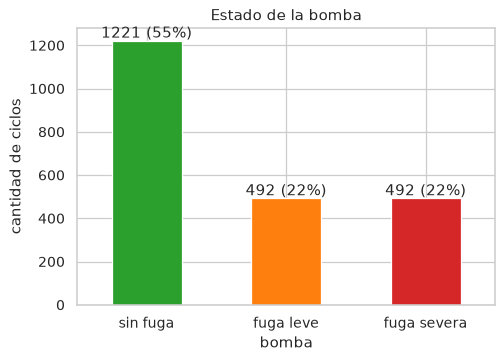

In [4]:
conteo = perfil["bomba"].map(NOMBRES_BOMBA).value_counts().reindex(NOMBRES_BOMBA.values())
ax = conteo.plot.bar(color=["tab:green", "tab:orange", "tab:red"], figsize=(6, 4), rot=0)
for i, v in enumerate(conteo):
    ax.text(i, v + 15, f"{v} ({v / len(perfil):.0%})", ha="center")
ax.set_ylabel("cantidad de ciclos")
ax.set_title("Estado de la bomba")
plt.show()

El 55% de los ciclos son "sin fuga" y el resto se reparte en partes iguales entre fuga leve y severa. No es un desbalance extremo, pero hay que tenerlo en cuenta: un "modelo" que conteste siempre *sin fuga* ya acertaría el 55% de las veces sin haber aprendido nada. Por eso el *accuracy* (porcentaje de aciertos) solo no alcanza para medir y vamos a usar otras métricas (sección 6).

### 3.2 Cómo se hizo el experimento, y por qué importa

Graficamos los estados del enfriador y de la bomba, y la temperatura media del aceite, a lo largo de los 2205 ciclos en el orden en que se registraron.

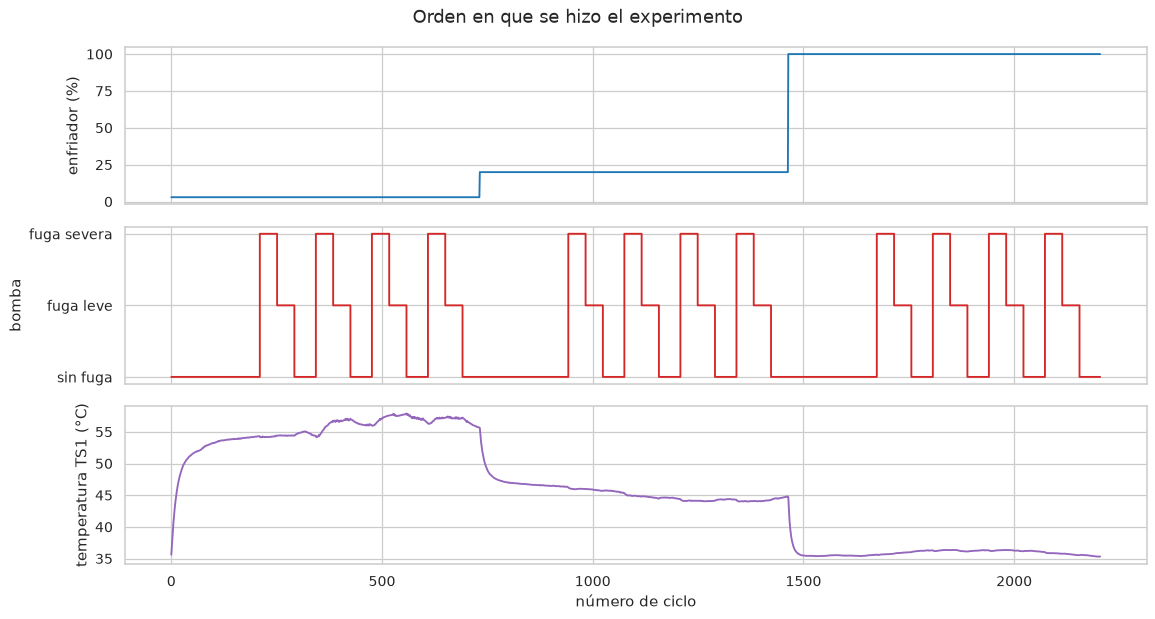

etapa 1 (enfriador casi sin funcionar): ciclos 0 a 731, temperatura media 55.0 °C
etapa 2 (enfriador a media capacidad): ciclos 732 a 1463, temperatura media 45.5 °C
etapa 3 (enfriador funcionando bien): ciclos 1464 a 2204, temperatura media 36.0 °C


In [5]:
ciclo = np.arange(len(perfil))
temp_media = crudo["TS1"].mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
axes[0].plot(ciclo, perfil["enfriador"], color="tab:blue")
axes[0].set_ylabel("enfriador (%)")
axes[1].plot(ciclo, y, color="tab:red", drawstyle="steps-post")
axes[1].set_yticks([0, 1, 2], list(NOMBRES_BOMBA.values()))
axes[1].set_ylabel("bomba")
axes[2].plot(ciclo, temp_media, color="tab:purple")
axes[2].set_ylabel("temperatura TS1 (°C)")
axes[2].set_xlabel("número de ciclo")
fig.suptitle("Orden en que se hizo el experimento")
plt.tight_layout()
plt.show()

for valor, nombre in NOMBRES_ETAPA.items():
    idx = np.flatnonzero(etapa == valor)
    print(f"{nombre}: ciclos {idx.min()} a {idx.max()}, "
          f"temperatura media {temp_media[idx].mean():.1f} °C")

De este gráfico sacamos dos cosas que condicionan todo el resto del trabajo:

1. **El experimento se hizo en tres etapas, una por cada estado del enfriador.** Como el enfriador es el que mantiene fría el aceite, cada etapa trabaja a una temperatura distinta: unos 55 °C en la primera, 45 °C en la segunda y 36 °C en la tercera. La temperatura cambia la viscosidad del aceite, así que también cambia lo que miden casi todos los sensores, aunque la bomba esté igual. El paper original menciona este mismo efecto.

2. **El estado de la bomba cambia más o menos cada 40 ciclos.** Eso quiere decir que hay tandas de ciclos seguidos con exactamente las mismas condiciones, y esos ciclos son casi idénticos entre sí. Si mezclamos los ciclos al azar para separar entrenamiento y test, el modelo va a ver en el test ciclos "gemelos" de los que ya vio en el entrenamiento. Eso se llama **fuga de información** (*data leakage*) y da resultados mejores que los reales. Lo resolvemos en la sección 5.

### 3.3 ¿Qué cambia en las señales cuando hay fuga?

Para ver el efecto de la bomba sin que se mezcle la temperatura, tomamos sólo los ciclos de la etapa 3 y promediamos las señales de cada estado de la bomba.

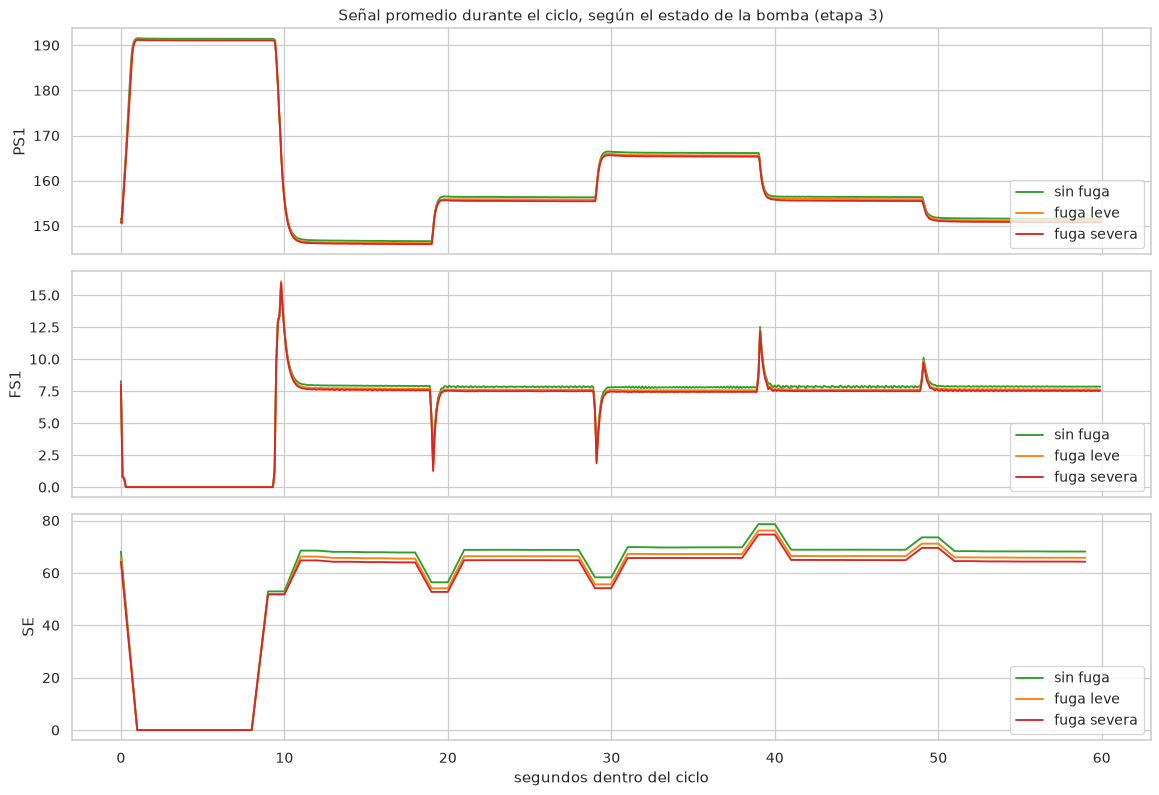

In [6]:
mask_e3 = (etapa == 100) & (perfil["estable"] == 0)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for sensor, ax, hz in [("PS1", axes[0], 100), ("FS1", axes[1], 10), ("SE", axes[2], 1)]:
    t = np.arange(crudo[sensor].shape[1]) / hz
    for clase, color in zip([0, 1, 2], ["tab:green", "tab:orange", "tab:red"]):
        curva = crudo[sensor][mask_e3 & (y == clase)].mean(axis=0)
        ax.plot(t, curva, color=color, label=NOMBRES_BOMBA[clase])
    ax.set_ylabel(sensor)
    ax.legend(loc="lower right")
axes[0].set_title("Señal promedio durante el ciclo, según el estado de la bomba (etapa 3)")
axes[2].set_xlabel("segundos dentro del ciclo")
plt.tight_layout()
plt.show()

- **PS1** (presión a la salida de la bomba) muestra la forma del ciclo: una serie de escalones de carga que se repiten igual en todos los ciclos. Las tres curvas se superponen casi por completo.
- **FS1** (caudal) baja un poco cuando hay fuga, que es lo esperable: si parte del aceite se vuelve, llega menos al circuito.
- **SE** (factor de eficiencia, un valor calculado por el sistema) es donde más se nota. Durante los primeros 9 segundos vale casi cero en los tres casos, y después, en todos los escalones de carga, la eficiencia con fuga queda unos 2 a 4 puntos por debajo de la de la bomba sana.

Ahora miramos lo mismo pero con un solo número por ciclo (el promedio de SE y de FS1), y separando por etapa:

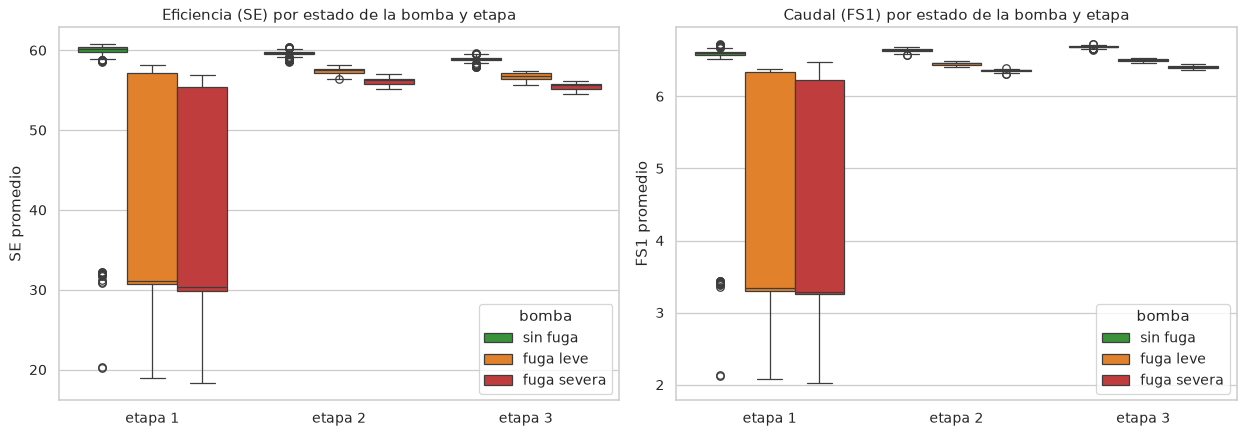

In [7]:
df_eda = pd.DataFrame({
    "SE promedio": crudo["SE"].mean(axis=1),
    "FS1 promedio": crudo["FS1"].mean(axis=1),
    "bomba": perfil["bomba"].map(NOMBRES_BOMBA),
    "etapa": perfil["enfriador"].map({3: "etapa 1", 20: "etapa 2", 100: "etapa 3"}),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["SE promedio", "FS1 promedio"]):
    sns.boxplot(data=df_eda, x="etapa", y=col, hue="bomba", ax=ax,
                hue_order=list(NOMBRES_BOMBA.values()),
                palette=["tab:green", "tab:orange", "tab:red"])
    ax.set_xlabel("")
axes[0].set_title("Eficiencia (SE) por estado de la bomba y etapa")
axes[1].set_title("Caudal (FS1) por estado de la bomba y etapa")
plt.tight_layout()
plt.show()

En las etapas 2 y 3 la eficiencia promedio separa bien los tres estados de la bomba, aunque las diferencias son chicas (uno o dos puntos) y los niveles se corren un poco de una etapa a otra. Por ejemplo, la bomba sana de la etapa 3 está más cerca de la fuga leve de la etapa 2 que de la bomba sana de la etapa 2. Con el caudal pasa lo mismo.

La etapa 1 es distinta: con fuga, la eficiencia promedio va desde valores normales hasta 20 o 30%. Miramos algunos de esos ciclos para entender qué pasaba:

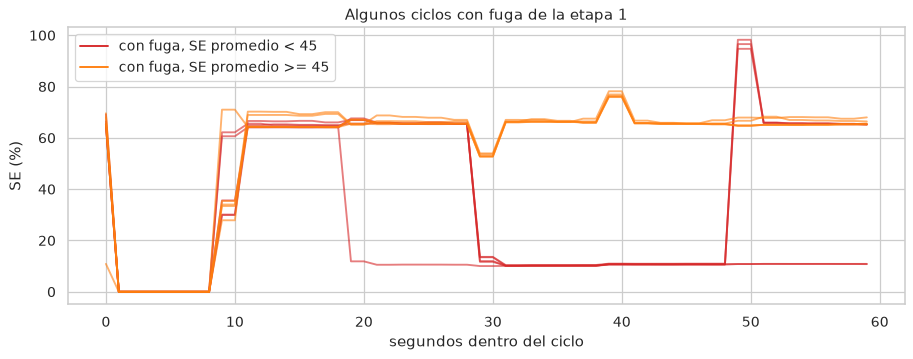

Ciclos con fuga en la etapa 1 según el estado del acumulador:


SE promedio < 45,False,True
acumulador (bar),,
90,9,73
100,4,78
115,12,70
130,78,4


In [8]:
e1_fuga = (etapa == 3) & (y > 0)
se_prom = crudo["SE"].mean(axis=1)
t = np.arange(60)

fig, ax = plt.subplots(figsize=(12, 4))
for i in np.flatnonzero(e1_fuga & (se_prom < 45))[:5]:
    ax.plot(t, crudo["SE"][i], color="tab:red", alpha=0.6)
for i in np.flatnonzero(e1_fuga & (se_prom >= 45))[:5]:
    ax.plot(t, crudo["SE"][i], color="tab:orange", alpha=0.6)
ax.plot([], [], color="tab:red", label="con fuga, SE promedio < 45")
ax.plot([], [], color="tab:orange", label="con fuga, SE promedio >= 45")
ax.set_xlabel("segundos dentro del ciclo")
ax.set_ylabel("SE (%)")
ax.set_title("Algunos ciclos con fuga de la etapa 1")
ax.legend()
plt.show()

print("Ciclos con fuga en la etapa 1 según el estado del acumulador:")
pd.crosstab(perfil.loc[e1_fuga, "acumulador"], se_prom[e1_fuga] < 45,
            rownames=["acumulador (bar)"], colnames=["SE promedio < 45"])

En esos ciclos la eficiencia arranca normal y en algún momento cae a un 11% y se queda ahí gran parte del ciclo. Pasa casi siempre cuando, además de la fuga en la bomba, el acumulador está deteriorado (menos de 130 bar) y el aceite está caliente. Parece una interacción entre fallas que no vamos a estudiar en este trabajo, pero tiene una consecuencia práctica: **el promedio de SE se hunde en esos ciclos, aunque en el resto del ciclo la eficiencia tenga un nivel parecido al de cualquier otro ciclo con fuga leve**.

Conclusión del análisis exploratorio: la eficiencia (SE) y el caudal (FS1) son las señales que más informan sobre la bomba, pero sus valores dependen también de la temperatura y de otras fallas. Por eso esperamos que una regla de un solo umbral funcione razonablemente, pero no del todo.

## 4. De señales a una tabla: extracción de características

Si usáramos todas las mediciones tal cual vienen, cada ciclo tendría 43.680 columnas (7 sensores × 6000 + 2 × 600 + 8 × 60) para sólo 2205 ciclos. Con tantas columnas y tan pocas filas los modelos que vimos en la materia funcionan mal: las distancias entre puntos dejan de ser informativas (lo que se conoce como *maldición de la dimensionalidad*) y es muy fácil sobreajustar.

Lo que hacemos, igual que en el paper original, es **resumir cada señal de cada ciclo con unos pocos números** (en la materia esto se llama *feature engineering* o extracción de características). Para cada sensor calculamos 12 estadísticos:

| Estadístico | Qué nos dice de la señal |
|---|---|
| `mean` | valor promedio |
| `std` | cuánto varía alrededor del promedio |
| `min`, `max` | valores extremos |
| `range` | máximo menos mínimo |
| `q10`, `q25`, `q50`, `q75`, `q90` | percentiles: por ejemplo `q90` es el valor que sólo superan el 10% de las mediciones del ciclo. `q50` es la mediana |
| `rms` | raíz del promedio de los cuadrados, una medida de "energía" de la señal |
| `slope` | diferencia entre el último y el primer valor del ciclo, dividida por la cantidad de mediciones (si la señal tiende a subir o a bajar) |

Así pasamos a una tabla de 2205 filas × 204 columnas (17 sensores × 12 estadísticos).

In [9]:
def extraer_features(datos, nombre):
    # datos: matriz (ciclos x mediciones) de un sensor
    f = {
        f"{nombre}_mean": datos.mean(axis=1),
        f"{nombre}_std": datos.std(axis=1),
        f"{nombre}_min": datos.min(axis=1),
        f"{nombre}_max": datos.max(axis=1),
    }
    for q in [10, 25, 50, 75, 90]:
        f[f"{nombre}_q{q}"] = np.percentile(datos, q, axis=1)
    f[f"{nombre}_range"] = f[f"{nombre}_max"] - f[f"{nombre}_min"]
    f[f"{nombre}_rms"] = np.sqrt((datos ** 2).mean(axis=1))
    f[f"{nombre}_slope"] = (datos[:, -1] - datos[:, 0]) / datos.shape[1]
    return pd.DataFrame(f)


X = pd.concat([extraer_features(crudo[s], s) for s in SENSORES], axis=1)
print("Tabla de features:", X.shape)
print("Valores faltantes o infinitos:", (~np.isfinite(X.to_numpy())).sum())
X.iloc[:5, :12]

Tabla de features: (2205, 204)
Valores faltantes o infinitos: 0


,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_q10,PS1_q25,PS1_q50,PS1_q75,PS1_q90,PS1_range,PS1_rms,PS1_slope
0,160.673752,13.938125,145.830002,191.509995,146.100006,151.190002,156.250000,166.309998,191.270004,45.679993,161.277466,-0.000047
1,160.602661,14.117697,145.729996,191.470001,146.089996,150.919998,156.059998,166.050003,191.240005,45.740005,161.222321,-0.000042
2,160.347488,14.191456,145.369995,191.410004,145.940002,150.589996,155.720001,165.869995,191.169998,46.040009,160.975037,-0.000032
3,160.188141,14.226619,145.139999,191.339996,145.809998,150.410004,155.559998,165.720001,191.110992,46.199997,160.818939,-0.000033
4,159.999527,14.275260,144.949997,191.410004,145.649994,150.190002,155.339996,165.490005,191.059998,46.460007,160.635986,-0.000037


## 5. División en entrenamiento y test

Separamos los datos en dos partes:

- **Entrenamiento:** lo que el modelo usa para aprender. Dentro de esta parte también hacemos la búsqueda de hiperparámetros con validación cruzada.
- **Test:** lo guardamos y no lo tocamos hasta el final. Sirve para estimar cómo andaría el modelo con datos que nunca vio.

La forma habitual es separar al azar (por ejemplo con `train_test_split`), pero acá no sirve por lo que vimos en 3.2: los ciclos vecinos son casi copias, y un reparto al azar pone "gemelos" a los dos lados.

La primera idea que tuvimos fue cortar por tiempo: entrenar con el primer 75% de los ciclos y testear con el último 25%, que es como funcionaría en la realidad (se aprende del pasado y se predice el futuro). El problema es que ese último 25% cae entero dentro de la etapa 3, la más fría, y casi todo el entrenamiento viene de las etapas 1 y 2, más calientes. Probamos y varios modelos se rompieron: predecían la misma clase para todos los ciclos. No era que no pudieran detectar la fuga, sino que estábamos evaluando con una temperatura que casi no habían visto (lo mostramos en la sección 11).

**Lo que hicimos finalmente:** cortar por tiempo, pero **dentro de cada etapa**. En cada una de las tres etapas, el primer 75% de los ciclos va a entrenamiento y el último 25% a test. Así:

- el test sigue siendo "el futuro" respecto del entrenamiento de su misma etapa,
- las tres temperaturas están representadas en los dos conjuntos,
- y las tres clases de la bomba aparecen en el test.

Queda un detalle: en el límite entre entrenamiento y test de cada etapa, el último ciclo de entrenamiento y el primero de test son vecinos. Son sólo tres límites, así que el efecto es chico.

In [10]:
es_test = np.zeros(len(perfil), dtype=bool)
for valor in [3, 20, 100]:
    idx = np.flatnonzero(etapa == valor)   # ciclos de esta etapa, en orden
    corte = int(len(idx) * 0.75)
    es_test[idx[corte:]] = True

X_train, X_test = X[~es_test], X[es_test]
y_train, y_test = y[~es_test], y[es_test]

print(f"Entrenamiento: {len(y_train)} ciclos | Test: {len(y_test)} ciclos\n")
tabla = pd.DataFrame({
    "entrenamiento": pd.Series(y_train).map(NOMBRES_BOMBA).value_counts(),
    "test": pd.Series(y_test).map(NOMBRES_BOMBA).value_counts(),
}).reindex(NOMBRES_BOMBA.values())
tabla

Entrenamiento: 1653 ciclos | Test: 552 ciclos



,entrenamiento,test
sin fuga,936,285
fuga leve,348,144
fuga severa,369,123


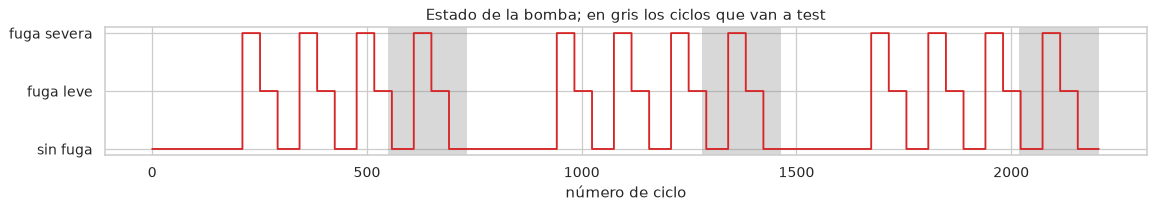

In [11]:
fig, ax = plt.subplots(figsize=(13, 2.5))
ax.plot(ciclo, y, color="tab:red", drawstyle="steps-post")
for i in np.flatnonzero(es_test):
    ax.axvspan(i, i + 1, color="gray", alpha=0.3, lw=0)
ax.set_yticks([0, 1, 2], list(NOMBRES_BOMBA.values()))
ax.set_xlabel("número de ciclo")
ax.set_title("Estado de la bomba; en gris los ciclos que van a test")
plt.tight_layout()
plt.show()

## 6. ¿Cómo medimos si un modelo es bueno?

Primero pensamos qué errores puede cometer el modelo y cuánto cuesta cada uno en la práctica:

- **Falsa alarma:** la bomba está sana y el modelo dice que tiene fuga. Consecuencia: se para el equipo para revisar algo que estaba bien. Es tiempo de producción perdido.
- **Fuga no detectada:** la bomba tiene fuga y el modelo dice que está sana. Consecuencia: el equipo sigue funcionando con menos rendimiento y la falla puede agravarse.
- **Confundir leve con severa:** detecta la fuga pero se equivoca en la gravedad. Es el error menos grave de los tres, porque igual se revisaría la bomba.

Discutimos bastante cuál de los dos primeros es peor. En una línea de producción una falsa alarma tiene un costo concreto y seguro, mientras que el costo de una fuga no detectada depende de cuánto tarde en agravarse. No tenemos información de costos reales para decidirlo, así que hicimos lo siguiente:

1. Para **comparar y elegir modelos** usamos el **F1 macro**. El F1 de una clase combina la *precisión* (de los ciclos que el modelo marcó con esa clase, cuántos lo eran de verdad) y el *recall* o sensibilidad (de los ciclos que eran de esa clase, cuántos encontró el modelo). El "macro" quiere decir que se calcula el F1 de cada una de las tres clases y se promedian sin ponderar, así que la clase mayoritaria (*sin fuga*) no tapa lo que pasa con las otras dos.
2. Además reportamos por separado los dos errores que más nos importan:
   - **% de falsas alarmas:** de los ciclos sin fuga, qué porcentaje el modelo marcó con fuga (leve o severa). Es lo mismo que 1 menos la *especificidad* de la clase sin fuga.
   - **% de fugas no detectadas:** de los ciclos con fuga (leve o severa), qué porcentaje el modelo marcó como sin fuga.
3. Y miramos la **matriz de confusión**, que muestra todos los aciertos y errores clase por clase.

In [12]:
CLASES = [0, 1, 2]


def evaluar(nombre, y_real, y_pred):
    cm = confusion_matrix(y_real, y_pred, labels=CLASES)
    falsas_alarmas = cm[0, 1:].sum() / cm[0].sum()
    fugas_no_detectadas = cm[1:, 0].sum() / cm[1:].sum()
    return {
        "modelo": nombre,
        "F1 macro test": f1_score(y_real, y_pred, average="macro"),
        "accuracy test": accuracy_score(y_real, y_pred),
        "% falsas alarmas": 100 * falsas_alarmas,
        "% fugas no detectadas": 100 * fugas_no_detectadas,
    }


def graficar_confusion(y_real, y_pred, titulo, ax=None):
    ConfusionMatrixDisplay.from_predictions(
        y_real, y_pred, labels=CLASES, display_labels=list(NOMBRES_BOMBA.values()),
        cmap="Blues", colorbar=False, ax=ax)
    (ax or plt.gca()).set_title(titulo)
    (ax or plt.gca()).set_xlabel("predicción del modelo")
    (ax or plt.gca()).set_ylabel("estado real")


resultados = []  # acá vamos guardando los resultados de cada modelo

## 7. Baseline: una regla simple, sin machine learning

Antes de entrenar cualquier modelo necesitamos un punto de comparación. Si un modelo complejo no le gana a una regla que se arma en cinco minutos, no vale la pena.

Usamos dos referencias:

- **Piso mínimo:** contestar siempre la clase más frecuente (*sin fuga*). Es lo que hace `DummyClassifier`.
- **Baseline con criterio:** una regla armada a partir del análisis exploratorio. En los boxplots de la sección 3.3 vimos que la eficiencia promedio (SE) baja con la fuga. La regla es:
  - si `SE_mean` es mayor que un umbral alto → *sin fuga*
  - si está entre los dos umbrales → *fuga leve*
  - si es menor que el umbral bajo → *fuga severa*

  Para cada umbral tomamos el punto medio entre las medianas de dos clases vecinas, calculadas **sólo con los datos de entrenamiento** (si usáramos el test para elegir los umbrales estaríamos haciendo trampa).

In [13]:
medianas = pd.Series(X_train["SE_mean"].to_numpy()).groupby(y_train).median()
umbral_alto = (medianas[0] + medianas[1]) / 2
umbral_bajo = (medianas[1] + medianas[2]) / 2
print("Mediana de SE_mean por clase (entrenamiento):")
print(medianas.rename(NOMBRES_BOMBA).round(2))
print(f"\nUmbral alto: {umbral_alto:.2f} %  |  Umbral bajo: {umbral_bajo:.2f} %")


def regla_baseline(df):
    se = df["SE_mean"].to_numpy()
    return np.where(se > umbral_alto, 0, np.where(se > umbral_bajo, 1, 2))


pred_base = regla_baseline(X_test)
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

resultados.append({**evaluar("Siempre 'sin fuga' (dummy)", y_test, dummy.predict(X_test)),
                   "F1 macro CV": np.nan})
resultados.append({**evaluar("Baseline: umbrales sobre SE", y_test, pred_base),
                   "F1 macro CV": f1_score(y_train, regla_baseline(X_train), average="macro")})
pd.DataFrame(resultados).set_index("modelo").round(3)

Mediana de SE_mean por clase (entrenamiento):
sin fuga       59.630001
fuga leve      57.029999
fuga severa    55.689999
dtype: float32

Umbral alto: 58.33 %  |  Umbral bajo: 56.36 %


,F1 macro test,accuracy test,% falsas alarmas,% fugas no detectadas,F1 macro CV
modelo,,,,,
Siempre 'sin fuga' (dummy),0.227,0.516,0.000,100.0,NaN
Baseline: umbrales sobre SE,0.766,0.806,11.579,0.0,0.845


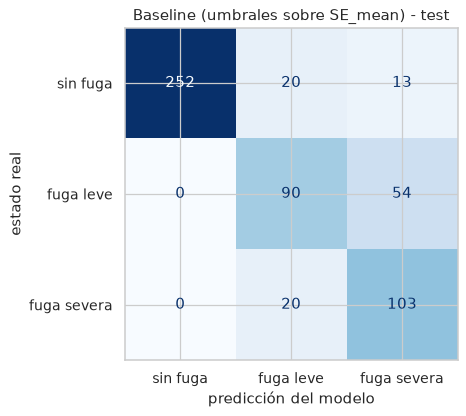

Errores del baseline en test, por etapa:


real                                     fuga leve fuga severa  sin fuga  \
predicho                               fuga severa   fuga leve fuga leve   
etapa                                                                      
etapa 1 (enfriador casi sin funcionar)          44           1         0   
etapa 2 (enfriador a media capacidad)            0          19         0   
etapa 3 (enfriador funcionando bien)            10           0        20   

real                                                
predicho                               fuga severa  
etapa                                               
etapa 1 (enfriador casi sin funcionar)          13  
etapa 2 (enfriador a media capacidad)            0  
etapa 3 (enfriador funcionando bien)             0

In [14]:
graficar_confusion(y_test, pred_base, "Baseline (umbrales sobre SE_mean) - test")
plt.show()

errores = pred_base != y_test
print("Errores del baseline en test, por etapa:")
pd.crosstab(pd.Series(etapa[es_test][errores]).map(NOMBRES_ETAPA).rename("etapa"),
            [pd.Series(y_test[errores]).map(NOMBRES_BOMBA).rename("real"),
             pd.Series(pred_base[errores]).map(NOMBRES_BOMBA).rename("predicho")])

*(Para el baseline, la columna "F1 macro CV" es en realidad el F1 sobre todo el entrenamiento, porque la regla no tiene nada que validar.)*

El dummy saca un F1 macro bajísimo, como era de esperar: acierta el 52% de los ciclos de test pero nunca detecta una fuga.

La regla con umbrales anda bastante bien para ser tan simple. Detecta todas las fugas (0% de fugas no detectadas), pero tiene alrededor de un 12% de falsas alarmas y confunde bastante la fuga leve con la severa. La tabla de errores por etapa muestra que son justo los problemas que vimos en el análisis exploratorio:

- en la etapa 1, muchas fugas leves quedan marcadas como severas, y algunos ciclos sanos quedan marcados como fuga severa. En los dos casos son ciclos en los que el promedio de SE se hunde;
- en las etapas 2 y 3, los umbrales fijos quedan corridos respecto de los niveles de esa etapa, y aparecen falsas alarmas o confusiones entre leve y severa.

**Este es el número a superar: F1 macro ≈ 0,77.**

## 8. Modelos

Probamos las cuatro familias de modelos supervisados que vimos en la materia: KNN, SVM, árboles de decisión y ensambles (Random Forest y XGBoost).

### Cómo buscamos los hiperparámetros

Los **hiperparámetros** son las perillas que se fijan antes de entrenar, por ejemplo cuántos vecinos mira KNN o qué tan profundo puede crecer un árbol. Para elegirlos usamos **validación cruzada de 5 pliegues** (*5-fold cross validation*) **sólo sobre el conjunto de entrenamiento**: se divide el entrenamiento en 5 partes, se entrena con 4 y se mide con la quinta, y se repite 5 veces rotando. El promedio de esas 5 mediciones es el "F1 macro CV" de las tablas.

Dos detalles:

- Usamos `KFold(shuffle=False)`, es decir, los pliegues son bloques de ciclos consecutivos y no ciclos mezclados al azar. Es por la misma razón de la sección 5: si mezclamos, cada pliegue de validación tendría gemelos en los pliegues de entrenamiento y la validación daría números inflados.
- Para KNN, SVM, árbol y Random Forest probamos todas las combinaciones de una grilla de valores (`GridSearchCV`). Para XGBoost, que tiene muchos más hiperparámetros, usamos Optuna, que va eligiendo las próximas combinaciones a probar según cómo le fue con las anteriores (optimización bayesiana).

In [15]:
cv = KFold(n_splits=5, shuffle=False)
modelos = {}        # mejor versión de cada modelo, ya entrenada
scores_pliegue = {}  # F1 de cada pliegue de la validación cruzada


def ajustar(nombre, modelo, grilla):
    inicio = time.time()
    busqueda = GridSearchCV(modelo, grilla, cv=cv, scoring="f1_macro", n_jobs=-1)
    busqueda.fit(X_train, y_train)
    mejor = busqueda.best_estimator_  # GridSearchCV lo reentrena con todo el train
    modelos[nombre] = mejor
    i = busqueda.best_index_
    scores_pliegue[nombre] = [busqueda.cv_results_[f"split{k}_test_score"][i] for k in range(5)]
    resultados.append({**evaluar(nombre, y_test, mejor.predict(X_test)),
                       "F1 macro CV": busqueda.best_score_})
    print(f"{nombre}: mejores hiperparámetros {busqueda.best_params_}")
    print(f"F1 macro CV = {busqueda.best_score_:.3f}  ({time.time() - inicio:.0f} s)")
    return mejor

### 8.1 K vecinos más cercanos (KNN)

KNN no "aprende" una fórmula: para clasificar un ciclo nuevo busca los *k* ciclos del entrenamiento más parecidos (los más cercanos según una distancia) y le asigna la clase que más se repite entre ellos.

Como compara distancias, hay que **escalar** las variables: si no, una presión medida en cientos de bar pesaría muchísimo más que una vibración de décimas de mm/s. Usamos `StandardScaler` (resta la media y divide por el desvío de cada columna) dentro de un `Pipeline`, para que el escalado se calcule sólo con los pliegues de entrenamiento en cada vuelta de la validación cruzada.

Hiperparámetros: cantidad de vecinos `k`, si todos los vecinos votan igual o pesan más los más cercanos (`weights`), y el tipo de distancia (`p=1` Manhattan, `p=2` euclídea).

In [16]:
knn = Pipeline([("escalado", StandardScaler()), ("modelo", KNeighborsClassifier())])
ajustar("KNN", knn, {
    "modelo__n_neighbors": [3, 5, 7, 11, 15, 21, 31],
    "modelo__weights": ["uniform", "distance"],
    "modelo__p": [1, 2],
});

KNN: mejores hiperparámetros {'modelo__n_neighbors': 21, 'modelo__p': 1, 'modelo__weights': 'uniform'}
F1 macro CV = 0.730  (3 s)


### 8.2 Máquina de vectores de soporte (SVM)

La SVM busca la frontera que separa las clases dejando el mayor margen posible a los puntos más cercanos (los *vectores de soporte*). Con un **kernel RBF** la frontera puede ser curva.

Hiperparámetros:
- `C`: cuánto se penaliza que un punto quede del lado equivocado o dentro del margen. Un `C` grande ajusta mucho a los datos de entrenamiento (riesgo de sobreajuste) y uno chico deja una frontera más suave.
- `gamma`: qué tan "local" es la influencia de cada punto en el kernel RBF.

También necesita escalado. Usamos `class_weight="balanced"`, que hace que equivocarse en las clases menos frecuentes cueste más durante el entrenamiento, para compensar que *sin fuga* es la mayoría.

In [17]:
svm = Pipeline([("escalado", StandardScaler()),
                ("modelo", SVC(kernel="rbf", class_weight="balanced"))])
ajustar("SVM (RBF)", svm, {
    "modelo__C": [0.1, 1, 10, 100],
    "modelo__gamma": ["scale", 0.001, 0.01, 0.1],
});

SVM (RBF): mejores hiperparámetros {'modelo__C': 10, 'modelo__gamma': 0.001}
F1 macro CV = 0.824  (2 s)


### 8.3 Árbol de decisión

Un árbol de decisión hace una serie de preguntas del tipo "¿tal feature es mayor que tal valor?" y en cada hoja asigna una clase. Busca las preguntas que mejor separan las clases (usamos el criterio de Gini que vimos en clase).

Si se lo deja crecer sin límite termina memorizando el entrenamiento (sobreajuste). Lo controlamos con:
- `max_depth`: cuántas preguntas seguidas puede hacer como máximo.
- `min_samples_leaf`: cuántos ciclos tiene que haber como mínimo en cada hoja.

No necesita escalado, porque cada pregunta mira una sola variable por vez.

In [18]:
arbol = DecisionTreeClassifier(class_weight="balanced", random_state=SEMILLA)
ajustar("Árbol de decisión", arbol, {
    "max_depth": [2, 3, 4, 5, 6, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
});

Árbol de decisión: mejores hiperparámetros {'max_depth': 2, 'min_samples_leaf': 1}
F1 macro CV = 0.963  (1 s)


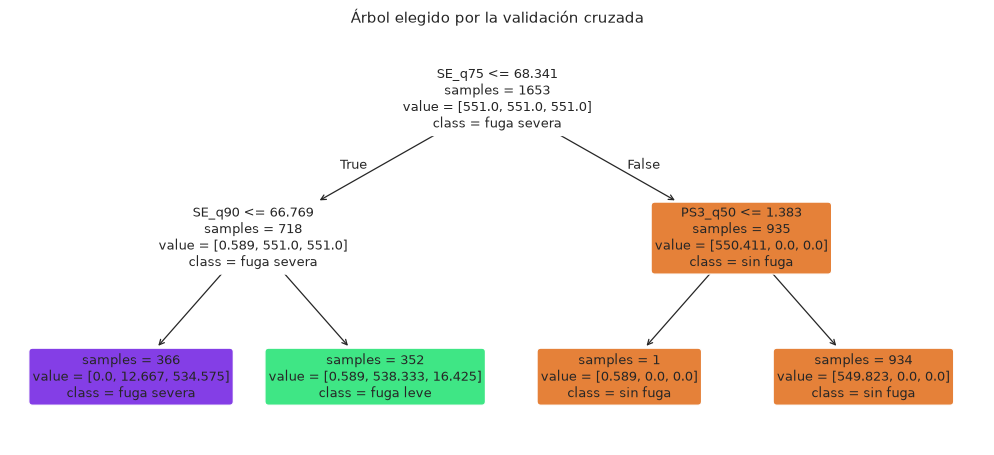

In [19]:
plt.figure(figsize=(14, 6))
plot_tree(modelos["Árbol de decisión"], feature_names=list(X.columns),
          class_names=list(NOMBRES_BOMBA.values()), filled=True, rounded=True,
          impurity=False, fontsize=10)
plt.title("Árbol elegido por la validación cruzada")
plt.show()

La validación cruzada eligió un árbol de **sólo dos niveles**, que se puede leer como una regla:

- Si `SE_q75` (el percentil 75 de la eficiencia en el ciclo) es alto → *sin fuga*.
- Si es bajo, se mira `SE_q90`: si es alto → *fuga leve*, si es bajo → *fuga severa*.

Es muy parecido a nuestro baseline, con dos diferencias: el árbol eligió los umbrales optimizando sobre los datos, y en lugar del promedio de SE usa sus **percentiles altos**. Tiene sentido con lo que vimos en el análisis exploratorio: el promedio se ve arrastrado por los tramos en los que SE vale casi cero (los primeros segundos) o se desploma (los ciclos raros de la etapa 1), mientras que el percentil 75 o 90 muestra el nivel de eficiencia de la bomba cuando está trabajando, que es donde se nota la fuga.

(En la rama derecha el árbol hace una pregunta sobre `PS3_q50` que no cambia la respuesta, porque las dos hojas dicen *sin fuga*. Es algo que pasa cuando se limita la profundidad: el árbol hizo esa división porque mejoraba un poco la pureza de las hojas, aunque no cambie la clase final.)

### 8.4 Random Forest

Un Random Forest entrena muchos árboles distintos y los hace votar. Cada árbol se entrena con una muestra al azar de los ciclos (con reposición, lo que se llama *bootstrap* o *bagging*) y en cada división sólo puede elegir entre un subconjunto al azar de las features. Así los árboles quedan distintos entre sí y, al promediarlos, se reduce la varianza de un árbol solo.

Hiperparámetros: `max_features` (qué fracción de features puede mirar en cada división), `min_samples_leaf` y `max_depth`. Dejamos fijos 300 árboles.

In [20]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            random_state=SEMILLA, n_jobs=-1)
ajustar("Random Forest", rf, {
    "max_features": ["sqrt", 0.3],
    "min_samples_leaf": [1, 5, 10],
    "max_depth": [None, 8],
});

Random Forest: mejores hiperparámetros {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 10}
F1 macro CV = 0.919  (26 s)


### 8.5 XGBoost (con Optuna)

XGBoost también combina muchos árboles, pero de otra forma (*boosting*): los entrena uno detrás de otro y cada árbol nuevo intenta corregir los errores que dejaron los anteriores. Cada árbol es chico ("débil") y su aporte se achica con la tasa de aprendizaje (`learning_rate`).

Tiene muchos hiperparámetros, así que en vez de una grilla usamos Optuna con 30 intentos. Para cada intento calcula el F1 macro con la misma validación cruzada que los demás modelos.

In [21]:
def objetivo(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
    }
    modelo = XGBClassifier(**params, random_state=SEMILLA, n_jobs=-1)
    return cross_val_score(modelo, X_train, y_train, cv=cv, scoring="f1_macro").mean()


inicio = time.time()
estudio = optuna.create_study(direction="maximize",
                              sampler=optuna.samplers.TPESampler(seed=SEMILLA))
estudio.optimize(objetivo, n_trials=30)

xgb = XGBClassifier(**estudio.best_params, random_state=SEMILLA, n_jobs=-1)
xgb.fit(X_train, y_train)
modelos["XGBoost"] = xgb
scores_pliegue["XGBoost"] = cross_val_score(xgb, X_train, y_train, cv=cv, scoring="f1_macro")
resultados.append({**evaluar("XGBoost", y_test, xgb.predict(X_test)),
                   "F1 macro CV": estudio.best_value})
print("XGBoost: mejores hiperparámetros", {k: round(v, 3) for k, v in estudio.best_params.items()})
print(f"F1 macro CV = {estudio.best_value:.3f}  ({time.time() - inicio:.0f} s)")

XGBoost: mejores hiperparámetros {'n_estimators': 202, 'max_depth': 2, 'learning_rate': 0.012, 'subsample': 0.98, 'colsample_bytree': 0.976}
F1 macro CV = 0.877  (83 s)


## 9. Comparación de resultados

In [22]:
tabla_resultados = (pd.DataFrame(resultados).set_index("modelo")
                    [["F1 macro CV", "F1 macro test", "accuracy test",
                      "% falsas alarmas", "% fugas no detectadas"]])
tabla_resultados.round(3)

,F1 macro CV,F1 macro test,accuracy test,% falsas alarmas,% fugas no detectadas
modelo,,,,,
Siempre 'sin fuga' (dummy),NaN,0.227,0.516,0.000,100.000
Baseline: umbrales sobre SE,0.845,0.766,0.806,11.579,0.000
KNN,0.730,0.957,0.960,4.561,0.749
SVM (RBF),0.824,0.996,0.996,0.351,0.000
Árbol de decisión,0.963,0.993,0.995,0.351,0.000
Random Forest,0.919,0.887,0.911,4.561,0.000
XGBoost,0.877,0.933,0.942,0.000,11.985


Cómo leer la tabla:

- **"F1 macro CV"** es lo que estimamos con validación cruzada dentro del entrenamiento. **Es la columna que usamos para elegir el modelo**, porque es la única que no usa el test.
- Las columnas de **test** son la evaluación final con datos que ningún modelo vio. Las miramos para confirmar la elección, no para hacerla. Si eligiéramos mirando el test, el test dejaría de ser una estimación honesta.

Lo que vemos:

- **Todos los modelos le ganan al baseline** (F1 macro ≈ 0,77) en el test, así que el machine learning aporta algo sobre la regla simple. La mejora viene sobre todo de bajar las falsas alarmas y de distinguir mejor leve de severa.
- **El árbol de decisión tiene el mejor F1 en validación cruzada** y en test anda prácticamente perfecto.
- **XGBoost no da ninguna falsa alarma, pero deja sin detectar el 12% de las fugas.** Son ciclos de fuga severa de la etapa 1, la que tiene los valores más raros de SE. Para un sistema de mantenimiento es el peor de los errores posibles, así que aunque su F1 sea aceptable no lo elegiríamos.
- **KNN y SVM tienen un F1 en validación cruzada mucho más bajo que en test.** El siguiente gráfico ayuda a entender por qué.

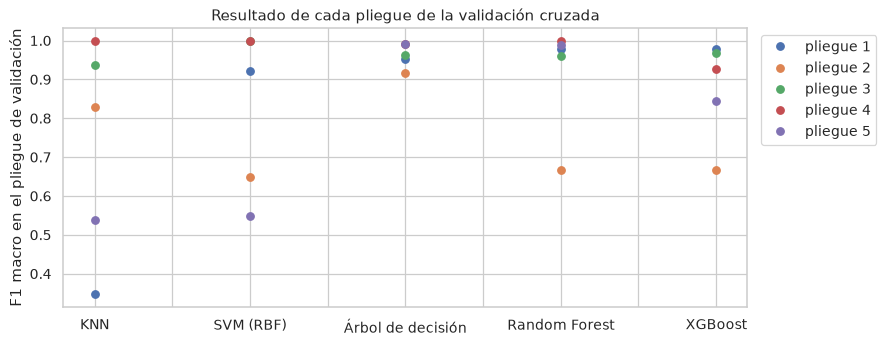

pliegue 1: etapa 1
pliegue 2: etapa 1, etapa 2
pliegue 3: etapa 2
pliegue 4: etapa 2, etapa 3
pliegue 5: etapa 3


In [23]:
pliegues = pd.DataFrame(scores_pliegue, index=[f"pliegue {k + 1}" for k in range(5)])
ax = pliegues.T.plot(marker="o", linestyle="", figsize=(10, 4))
ax.set_ylabel("F1 macro en el pliegue de validación")
ax.set_title("Resultado de cada pliegue de la validación cruzada")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# en qué etapa cae cada pliegue
etapa_train = etapa[~es_test]
for k, (_, idx_val) in enumerate(cv.split(X_train)):
    etapas = sorted({NOMBRES_ETAPA[e].split(" (")[0] for e in etapa_train[idx_val]})
    print(f"pliegue {k + 1}: {', '.join(etapas)}")

Como los pliegues son bloques de ciclos consecutivos, cada pliegue cae casi entero en una o dos etapas. Cuando un pliegue se usa para validar, los otros cuatro tienen pocos ciclos de esa misma etapa.

- **KNN y SVM** andan muy bien en algunos pliegues y muy mal en otros. Los dos trabajan con distancias entre ciclos calculadas con las 204 features (la SVM con kernel RBF también), y muchas de esas features dependen más de la temperatura que de la bomba. Cuando el pliegue de validación tiene una temperatura poco representada en el resto, los ciclos "más parecidos" son los de temperatura parecida y no los de la bomba en el mismo estado.
- **Random Forest y XGBoost** andan bien en casi todos los pliegues, pero caen en el pliegue 2, donde está la transición entre la etapa 1 y la 2.
- **El árbol de decisión** es el más parejo: su peor pliegue está por encima de 0,9. Usa pocas features (los percentiles de SE) e ignora el resto.

En el test a KNN y a la SVM les va bien porque el test y el entrenamiento tienen las tres temperaturas, así que siempre hay ciclos de la misma etapa para comparar. Pero la validación cruzada nos avisa que son modelos frágiles si cambia la temperatura de operación. En la sección 11 lo confirmamos.

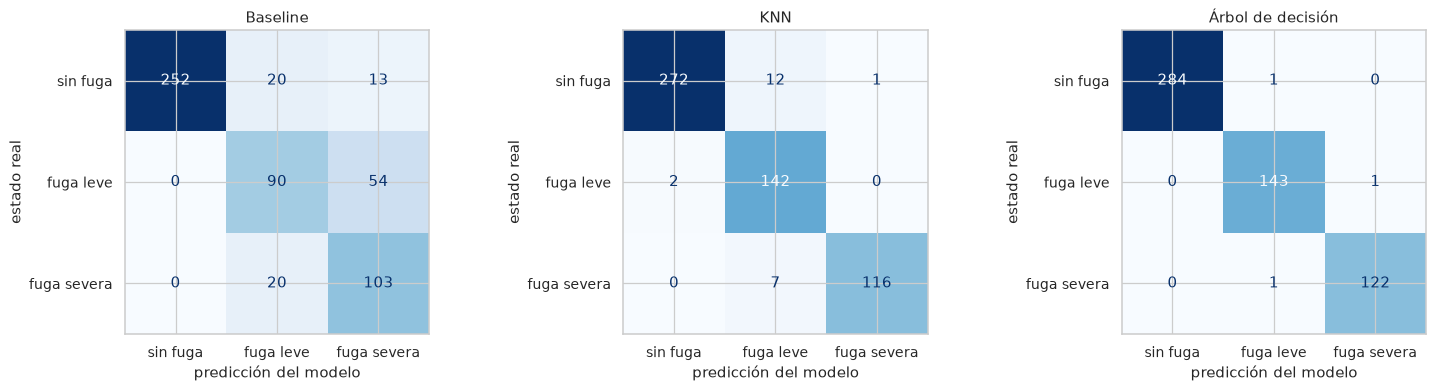

              precision    recall  f1-score   support

    sin fuga      1.000     0.996     0.998       285
   fuga leve      0.986     0.993     0.990       144
 fuga severa      0.992     0.992     0.992       123

    accuracy                          0.995       552
   macro avg      0.993     0.994     0.993       552
weighted avg      0.995     0.995     0.995       552



In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
graficar_confusion(y_test, pred_base, "Baseline", ax=axes[0])
graficar_confusion(y_test, modelos["KNN"].predict(X_test), "KNN", ax=axes[1])
graficar_confusion(y_test, modelos["Árbol de decisión"].predict(X_test), "Árbol de decisión", ax=axes[2])
plt.tight_layout()
plt.show()

print(classification_report(y_test, modelos["Árbol de decisión"].predict(X_test),
                            target_names=list(NOMBRES_BOMBA.values()), digits=3))

Las matrices de confusión muestran dónde se equivoca cada uno. El baseline marca como fuga a varios ciclos sanos (falsas alarmas, primera fila) y confunde fuga leve con severa. El árbol prácticamente no comete errores en el test: los pocos que hay son entre clases vecinas.

### ¿Qué features usan los modelos de ensamble?

El árbol de un solo modelo ya nos mostró que lo importante es SE. Miramos también la importancia de features del Random Forest para ver si coincide.

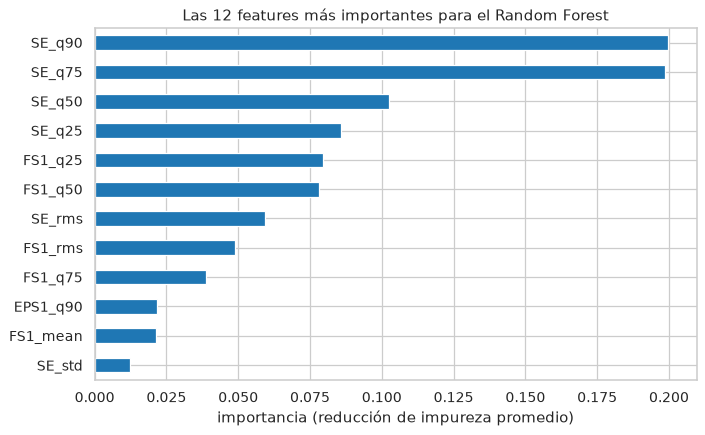

Importancia sumada por sensor:
SE      0.664
FS1     0.269
EPS1    0.056
TS2     0.005
PS1     0.002
PS2     0.001
dtype: float64


In [25]:
importancia = pd.Series(modelos["Random Forest"].feature_importances_, index=X.columns)
importancia.sort_values().tail(12).plot.barh(figsize=(8, 5), color="tab:blue")
plt.xlabel("importancia (reducción de impureza promedio)")
plt.title("Las 12 features más importantes para el Random Forest")
plt.tight_layout()
plt.show()

por_sensor = importancia.groupby(lambda c: c.split("_")[0]).sum().sort_values(ascending=False)
print("Importancia sumada por sensor:")
print(por_sensor.head(6).round(3))

El Random Forest coincide con el árbol: casi toda la importancia se la llevan la eficiencia (SE) y el caudal (FS1), que son justamente las dos señales donde vimos diferencias en el análisis exploratorio, y tiene sentido físico: si la bomba pierde aceite por una fuga interna, entrega menos caudal y rinde menos.

## 10. Elección del modelo

Elegimos el **árbol de decisión de profundidad 2**. Los motivos:

1. **Rendimiento:** tiene el mejor F1 macro en validación cruzada, que es el criterio que fijamos de antemano, y en test confirma ese resultado.
2. **Estabilidad:** es el que menos varía entre pliegues, o sea el menos sensible a la temperatura de operación (en la sección 11 se ve que también es el que mejor aguanta un cambio de temperatura entre entrenamiento y test).
3. **Simplicidad:** son dos preguntas sobre una sola señal. Se puede explicar a un técnico de mantenimiento y se podría programar en el controlador de la máquina sin necesidad de librerías de machine learning.
4. **Costo:** entrena y predice en milisegundos.

La SVM saca un poco más en test (0,996 contra 0,993, que es una diferencia de un solo ciclo), pero en validación cruzada queda bastante abajo y es mucho más difícil de interpretar. Random Forest y XGBoost no mejoran al árbol simple, así que en este problema la complejidad extra no se justifica.

Respecto al baseline, el árbol pasa de un F1 macro de 0,77 a 0,99 y baja las falsas alarmas de cerca del 12% a menos del 1%, sin dejar fugas sin detectar.

### Una observación sobre el baseline

El árbol es, en el fondo, una regla de umbrales como nuestro baseline, sólo que sobre otra variable. Nos preguntamos qué hubiera pasado si en el análisis exploratorio hubiéramos elegido el percentil 90 de SE en vez del promedio, con el mismo método de umbrales:

In [26]:
mediana_q90 = pd.Series(X_train["SE_q90"].to_numpy()).groupby(y_train).median()
alto = (mediana_q90[0] + mediana_q90[1]) / 2
bajo = (mediana_q90[1] + mediana_q90[2]) / 2
se_q90 = X_test["SE_q90"].to_numpy()
pred_q90 = np.where(se_q90 > alto, 0, np.where(se_q90 > bajo, 1, 2))
pd.DataFrame([evaluar("Regla de umbrales sobre SE_q90", y_test, pred_q90)]).set_index("modelo").round(3)

,F1 macro test,accuracy test,% falsas alarmas,% fugas no detectadas
modelo,,,,
Regla de umbrales sobre SE_q90,0.987,0.991,0.0,0.0


La misma regla simple, con la variable que encontró el árbol, llega casi al mismo resultado. Esta prueba la hicimos después de ver los resultados, así que no la usamos para elegir nada; la mostramos porque cambia cómo interpretamos lo que pasó. En este problema **lo valioso del modelo no fue tanto la capacidad de predecir como la de encontrar cuál era la variable correcta** entre las 204. Nosotros, mirando boxplots, habíamos elegido el promedio porque era lo más natural, y el árbol encontró que el percentil alto separaba mejor.

## 11. ¿Qué hubiera pasado si dividíamos los datos de otra forma?

Para mostrar por qué nos preocupamos tanto por la división de los datos, reentrenamos los modelos elegidos (con los mismos hiperparámetros) usando las otras dos divisiones que mencionamos en la sección 5:

- **Al azar:** 75/25 mezclando todos los ciclos (con `train_test_split`, estratificado por clase).
- **Corte temporal único:** primer 75% de los ciclos para entrenar y último 25% para test.

In [27]:
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X, y, test_size=0.25, stratify=y,
                                              random_state=SEMILLA)
corte = int(len(X) * 0.75)
divisiones = {
    "al azar": (Xa_tr, Xa_te, ya_tr, ya_te),
    "corte temporal único": (X.iloc[:corte], X.iloc[corte:], y[:corte], y[corte:]),
    "por etapa (la nuestra)": (X_train, X_test, y_train, y_test),
}

filas = []
for nombre_div, (a, b, c, d) in divisiones.items():
    fila = {"división": nombre_div}
    for nombre_mod in ["KNN", "SVM (RBF)", "Árbol de decisión", "Random Forest"]:
        m = clone(modelos[nombre_mod]).fit(a, c)
        fila[nombre_mod] = f1_score(d, m.predict(b), average="macro")
    filas.append(fila)
pd.DataFrame(filas).set_index("división").round(3)

,KNN,SVM (RBF),Árbol de decisión,Random Forest
división,,,,
al azar,0.971,0.990,0.982,0.987
corte temporal único,0.192,0.192,0.998,0.994
por etapa (la nuestra),0.957,0.996,0.993,0.887


In [28]:
print("Temperatura media (TS1) en el corte temporal único:")
print(f"  entrenamiento: {temp_media[:corte].mean():.1f} °C")
print(f"  test:          {temp_media[corte:].mean():.1f} °C")

Temperatura media (TS1) en el corte temporal único:
  entrenamiento: 48.6 °C
  test:          36.0 °C


- **Al azar** todos los modelos dan valores muy altos y parecidos. Parte de eso es real (la fuga se puede detectar), pero no podemos separar cuánto es mérito del modelo y cuánto es que el test tiene ciclos casi idénticos a los del entrenamiento. Además, con esta división no se nota ninguna diferencia entre los modelos, y por lo tanto no nos ayuda a elegir.
- **Con el corte temporal único** KNN y SVM se desploman a un F1 de 0,19: predicen la misma clase para todos los ciclos. El test es todo de la etapa más fría (36 °C) y el entrenamiento es casi todo de etapas más calientes, así que las features que dependen de la temperatura quedan fuera del rango que vieron al entrenar. El árbol y el Random Forest, en cambio, siguen funcionando casi perfecto, porque se apoyan en las features de SE, que separan las clases de forma parecida en todas las temperaturas.
- **Con nuestra división por etapa** los cuatro modelos funcionan, y la validación cruzada (sección 9) ya nos había avisado cuáles eran frágiles.

Lo que sacamos de esta comparación es que la forma de dividir los datos cambia los resultados tanto como la elección del modelo. También refuerza la elección del árbol: es el único de los cuatro que superó 0,98 en las tres divisiones.

## 12. Conclusiones

**Respuesta a la pregunta.** Sí, con los sensores de un solo ciclo se puede detectar la fuga interna de la bomba y su gravedad con muy buena precisión. El modelo elegido, un árbol de decisión de dos niveles, obtuvo un F1 macro de 0,96 en validación cruzada y de 0,99 en test, contra 0,77 del baseline. La mejora está en que casi no da falsas alarmas y en que distingue bien la fuga leve de la severa.

**Lo que aprendimos:**

- **El baseline es importante.** Una regla de dos umbrales armada mirando un boxplot ya llegaba a 0,77. Eso nos dio una idea clara de cuánto aportaba cada modelo. Y al final descubrimos que el aporte principal del árbol fue mostrarnos qué variable usar para esa misma regla.
- **Entender cómo se generaron los datos fue lo que más influyó en el resultado.** Si no hubiéramos visto que el experimento tenía etapas con distinta temperatura y tandas de ciclos casi iguales, habríamos reportado números inflados (división al azar) o habríamos concluido que los modelos no sirven (corte temporal único).
- **El modelo más simple fue el mejor.** Random Forest y XGBoost no superaron al árbol de dos niveles. En un problema donde una señal concentra casi toda la información, la complejidad extra no paga.
- **Los modelos basados en distancias (KNN, SVM) sufren cuando hay variables que no tienen que ver con lo que queremos predecir** pero que cambian mucho (acá, la temperatura), porque todas las features pesan en la distancia.

**Limitaciones:**

- Son datos de un solo banco de pruebas, con un ciclo de carga que se repite siempre igual. En una máquina real el ciclo de trabajo varía, y el paper original muestra que con cargas aleatorias detectar la fuga de la bomba es bastante más difícil.
- El test tiene 552 ciclos que vienen de tres tramos de tiempo. Con tan pocos ciclos, una diferencia de uno o dos puntos de F1 entre dos modelos no alcanza para decir que uno es mejor que el otro.
- No sacamos los ciclos en los que el sistema todavía no estaba estable (la columna `estable` de `profile.txt`). Los dejamos porque en una máquina real tampoco se podría elegir, pero puede que estén afectando algunos resultados.

**Posibles próximos pasos:**

- Calcular las features por tramos del ciclo (por ejemplo, sólo en los escalones de carga alta), como hacen los autores del dataset, en lugar de sobre el ciclo completo.
- Agregar a las features alguna corrección por temperatura, para que los modelos basados en distancias no dependan de la etapa.
- Si se quisiera usar la probabilidad que da el modelo (por ejemplo, para decidir cuándo parar el equipo según un umbral de riesgo), revisar la calibración de esas probabilidades, como vimos en la clase 7.
- Aplicar el mismo procedimiento al acumulador, que según el paper es el componente más difícil.

## Referencias

- Dataset: ZeMA gGmbH, *Condition monitoring of hydraulic systems*. UCI Machine Learning Repository (2018). Copia en Kaggle: https://www.kaggle.com/datasets/jjacostupa/condition-monitoring-of-hydraulic-systems
- N. Helwig, E. Pignanelli, A. Schütze. *Condition Monitoring of a Complex Hydraulic System Using Multivariate Statistics*. IEEE I2MTC 2015. doi: 10.1109/I2MTC.2015.7151267
- T. Schneider, N. Helwig, A. Schütze. *Automatic feature extraction and selection for classification of cyclical time series data*. tm - Technisches Messen 84(3), 2017. doi: 10.1515/teme-2016-0072
- G. James, D. Witten, T. Hastie, R. Tibshirani. *An Introduction to Statistical Learning*. Springer.
- Material de clase de Aprendizaje de Máquina I, CEIA - FIUBA (repositorio de la materia).
- Documentación de scikit-learn, XGBoost y Optuna.